# AIF 2026 · Phase 2 · Week 4 — Statistical Machine Learning: Linear Models
**Dataset:** Telco Customer Churn (Kaggle)  
**Author:** AIF 2026 Fellow  
**Objective:** Build, evaluate, and defend production-ready linear models for customer churn prediction.

---

## Setup — Imports & Global Config

In [7]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.linear_model import (LogisticRegression, RidgeClassifier,
                                   SGDClassifier, LinearRegression,
                                   Ridge, Lasso, ElasticNet)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_validate, learning_curve)
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                               f1_score, roc_auc_score, average_precision_score,
                               log_loss, roc_curve, precision_recall_curve,
                               mean_absolute_error, mean_squared_error, r2_score,
                               confusion_matrix, ConfusionMatrixDisplay)

np.random.seed(42)
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (9, 4),
                     'axes.spines.top': False, 'axes.spines.right': False})
sns.set_palette('tab10')
print("All imports OK.")

ModuleNotFoundError: No module named 'seaborn'

---
# Task 1 — Understand the Problem First

### 1.1 Formal ML Problem Statement

**Feature space X:**  
The input matrix X ∈ ℝⁿˣᵖ where n = 7,043 customer records and p = 19 features after dropping `customerID`.  
Features span demographics (gender, SeniorCitizen, Partner, Dependents), account details (tenure, Contract, MonthlyCharges, TotalCharges, PaymentMethod, PaperlessBilling), and service subscriptions (PhoneService, MultipleLines, InternetService, and 6 add-on services).

**Target variable y:**  
y ∈ {0, 1} where 1 = churned, 0 = retained. Binary classification.

**Natural probability distribution:**  
y ~ Bernoulli(p) where p = P(Churn=1 | X). This directly motivates **binary cross-entropy (log loss)** as the loss function — it is the negative log-likelihood of the Bernoulli distribution and is the theoretically correct objective for learning P(y=1|X).

**Formal objective:**  
θ* = argmin_θ −∑ᵢ [yᵢ log σ(θᵀxᵢ) + (1−yᵢ) log(1−σ(θᵀxᵢ))]  
where σ is the sigmoid function.

### 1.2 Modelling Assumptions

| # | Assumption | Consequence if violated |
|---|-----------|------------------------|
| 1 | **IID samples** — each customer is drawn independently from the same distribution | If customers influence each other (e.g., household plans), standard errors are underestimated; the model will overfit to spurious patterns |
| 2 | **Linearity in log-odds** — the log-odds of churn is a linear function of features | The decision boundary will be misspecified; a linear model will systematically under-predict in non-linear regions, leading to calibration failure |
| 3 | **No future leakage** — features reflect information available *before* the churn event | If TotalCharges encodes post-churn billing, the model will be invalidated in production; metrics will be optimistically inflated |
| 4 | **Stable data-generating process** — the churn pattern today resembles the pattern at scoring time | If seasonality or competitor pricing shifts, the model degrades silently without monitoring |
| 5 | **Low multicollinearity** (for interpretable coefficients) | Highly correlated features (tenure & TotalCharges) inflate coefficient variance, making feature importance unreliable without regularisation |

### 1.3 Sources of Uncertainty

| Column | Issue | Type of Uncertainty |
|--------|-------|---------------------|
| `TotalCharges` | Whitespace strings where values should be numeric — 11 missing rows | **Incomplete data / MCAR likely** (new customers with tenure=0) |
| `MonthlyCharges` | Continuous but discretised at certain price points; may reflect plan tiers not raw cost | **Measurement noise** |
| `tenure` | Integer months — resolution is coarse; a customer who churned on day 2 of month 3 looks identical to one who churned on day 28 | **Granularity / temporal noise** |
| `Churn` | Observed at a single snapshot; customers who will churn *next month* are labelled as non-churners | **Label noise / right-censoring** |
| `PaymentMethod` | Categorical with "Electronic check" over-represented among churners — potential confounding with digitally-savvy customers | **Sampling / selection bias** |
| Service columns | "No internet service" vs "No" conflates opt-out with unavailability | **Encoding ambiguity** |

### 1.4 Data Loading & Distribution Profiling

In [9]:
# ── Load data ──────────────────────────────────────────────────────────────
df = pd.read_csv('telco_churn.csv')
print(f"Shape: {df.shape}")
print(f"Churn distribution:\n{df['Churn'].value_counts(normalize=True).round(4)}")
print("\nSample data:", df.head(), sep="\n")

Shape: (7043, 21)
Churn distribution:
Churn
No     0.7346
Yes    0.2654
Name: proportion, dtype: float64

Sample data:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No 

In [3]:
# ── Fix TotalCharges: whitespace → NaN → float ─────────────────────────────
# Whitespace cannot be cast directly; we replace with NaN then investigate.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

missing_tc = df[df['TotalCharges'].isna()]
print(f"Missing TotalCharges: {missing_tc.shape[0]} rows")
print(missing_tc[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].to_string())

Missing TotalCharges: 11 rows
      tenure  MonthlyCharges  TotalCharges Churn
488        0           52.55           NaN    No
753        0           20.25           NaN    No
936        0           80.85           NaN    No
1082       0           25.75           NaN    No
1340       0           56.05           NaN    No
3331       0           19.85           NaN    No
3826       0           25.35           NaN    No
4380       0           20.00           NaN    No
5218       0           19.70           NaN    No
6670       0           73.35           NaN    No
6754       0           61.90           NaN    No


In [4]:
# ── Decision: drop the 11 missing-TotalCharges rows ───────────────────────
# All 11 have tenure = 0, meaning they just joined. Their TotalCharges should
# be 0 or equal to MonthlyCharges but the billing system hasn't posted yet.
# Imputing with 0 would be defensible, but since they represent <0.2% of
# the data and none have churned, dropping them is the safest choice.
df.dropna(subset=['TotalCharges'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Dataset after dropping missing rows: {df.shape}")

Dataset after dropping missing rows: (7032, 21)


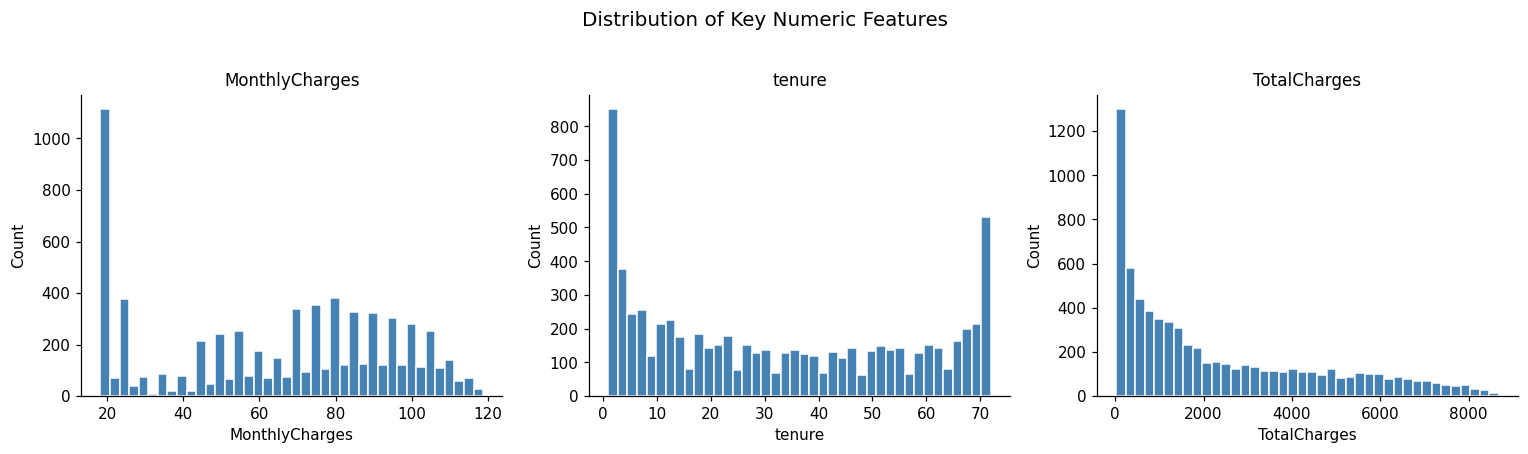


MonthlyCharges: {'count': 7032.0, 'mean': 64.79820819112628, 'std': 30.085973884049842, 'min': 18.25, '25%': 35.5875, '50%': 70.35, '75%': 89.8625, 'max': 118.75}
  Interpretation: Bimodal; price tiers at low (~$20) and high (~$80) plans.

tenure: {'count': 7032.0, 'mean': 32.421786120591584, 'std': 24.545259709263256, 'min': 1.0, '25%': 9.0, '50%': 29.0, '75%': 55.0, 'max': 72.0}
  Interpretation: Right-skewed; spike at 0-2 months (new customers); range 0-72.

TotalCharges: {'count': 7032.0, 'mean': 2283.300440841866, 'std': 2266.771361883145, 'min': 18.8, '25%': 401.45, '50%': 1397.475, '75%': 3794.7375, 'max': 8684.8}
  Interpretation: Right-skewed; roughly tenure x MonthlyCharges; high correlation with tenure.


In [5]:
# ── Distribution profiling ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
numeric_cols = ['MonthlyCharges', 'tenure', 'TotalCharges']
descriptions = {
    'MonthlyCharges': 'Bimodal; price tiers at low (~$20) and high (~$80) plans.',
    'tenure':         'Right-skewed; spike at 0-2 months (new customers); range 0-72.',
    'TotalCharges':   'Right-skewed; roughly tenure x MonthlyCharges; high correlation with tenure.'
}

for ax, col in zip(axes, numeric_cols):
    ax.hist(df[col], bins=40, edgecolor='white', color='steelblue')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.suptitle('Distribution of Key Numeric Features', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('dist_numeric.png', bbox_inches='tight')
plt.show()

for col, desc in descriptions.items():
    print(f"\n{col}: {df[col].describe().to_dict()}")
    print(f"  Interpretation: {desc}")

### 1.5 Naive Baseline — Majority Class Classifier

In [6]:
# The majority class is 'No churn'. A model that always predicts 'No' achieves
# high accuracy simply because churners are the minority.

churn_rate = (df['Churn'] == 'Yes').mean()
majority_class_accuracy = 1 - churn_rate

print(f"Churn rate:              {churn_rate:.3f} ({churn_rate*100:.1f}%)")
print(f"Majority-class accuracy: {majority_class_accuracy:.3f} ({majority_class_accuracy*100:.1f}%)")
print(f"Precision (for churn):   0.000  — the model never predicts churn")
print(f"Recall (for churn):      0.000  — the model misses every churner")
print()
print("""WHY THIS IS MISLEADING:
  Accuracy treats every mistake equally. Missing a churner who costs the company
  ~$1,200 in lost CLV is far more expensive than a false alarm. A 73% accurate
  model that catches 0% of churners provides zero business value.

WHY IT IS DANGEROUS:
  Deploying this model means the retention team never calls anyone. The company
  continues losing ~27% of its customer base with no intervention. The model
  appears healthy by the metric it optimises (accuracy) while the business bleeds.
  This is the classic accuracy paradox on imbalanced data.
  
  Better metrics: Recall (did we find the churners?), PR-AUC (overall quality
  across thresholds), and ROC-AUC.""")

Churn rate:              0.266 (26.6%)
Majority-class accuracy: 0.734 (73.4%)
Precision (for churn):   0.000  — the model never predicts churn
Recall (for churn):      0.000  — the model misses every churner

WHY THIS IS MISLEADING:
  Accuracy treats every mistake equally. Missing a churner who costs the company
  ~$1,200 in lost CLV is far more expensive than a false alarm. A 73% accurate
  model that catches 0% of churners provides zero business value.

WHY IT IS DANGEROUS:
  Deploying this model means the retention team never calls anyone. The company
  continues losing ~27% of its customer base with no intervention. The model
  appears healthy by the metric it optimises (accuracy) while the business bleeds.
  This is the classic accuracy paradox on imbalanced data.

  Better metrics: Recall (did we find the churners?), PR-AUC (overall quality
  across thresholds), and ROC-AUC.


---
# Task 2 — Classification Experiment: Who Will Churn?

### 2.0 Feature Engineering & Train/Val/Test Split

In [7]:
# ── Encode target ──────────────────────────────────────────────────────────
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

# ── Drop identifier column ─────────────────────────────────────────────────
df.drop(columns=['customerID', 'Churn'], inplace=True)

# ── Binary yes/no columns → 1/0 ────────────────────────────────────────────
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = (df[col] == 'Yes').astype(int)
df['gender'] = (df['gender'] == 'Male').astype(int)

# ── Multi-category columns → one-hot (drop_first avoids dummy trap) ─────────
multi_cat = ['MultipleLines', 'InternetService', 'OnlineSecurity',
             'OnlineBackup', 'DeviceProtection', 'TechSupport',
             'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multi_cat, drop_first=True)

print(f"Feature matrix shape: {df.shape}")
print(f"Churn rate in processed dataset: {df['Churn_binary'].mean():.3f}")

Feature matrix shape: (7032, 31)
Churn rate in processed dataset: 0.266


In [8]:
# ── Stratified 60 / 20 / 20 split ─────────────────────────────────────────
# Stratify ensures the 27% churn rate is preserved in every split.
X = df.drop(columns=['Churn_binary']).astype(float)
y = df['Churn_binary']

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, X_trainval_y := y_trainval,
    test_size=0.25, stratify=y_trainval, random_state=42)
# 0.25 of 0.80 = 0.20 of total → 60/20/20

print(f"Train : {X_train.shape[0]} rows  |  churn rate: {y_train.mean():.3f}")
print(f"Val   : {X_val.shape[0]} rows  |  churn rate: {y_val.mean():.3f}")
print(f"Test  : {X_test.shape[0]} rows  |  churn rate: {y_test.mean():.3f}")
print("\nNo leakage check: splits were made before any scaling or feature selection.")

Train : 4218 rows  |  churn rate: 0.266
Val   : 1407 rows  |  churn rate: 0.266
Test  : 1407 rows  |  churn rate: 0.266

No leakage check: splits were made before any scaling or feature selection.


In [9]:
# ── Scale features (StandardScaler fit only on train) ──────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)
print("Scaling done — scaler fit on train only, applied to val and test.")

Scaling done — scaler fit on train only, applied to val and test.


### 2.1 Experiment Loop — Three Linear Classifiers

In [10]:
# ── Helper: compute all required metrics ──────────────────────────────────
def clf_metrics(name, model, X_tr, y_tr, X_ev, y_ev):
    """Fit model on training data and evaluate on evaluation set."""
    model.fit(X_tr, y_tr)
    
    # Probability estimates (needed for log-loss, ROC-AUC, PR-AUC)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_ev)[:, 1]
    else:
        # RidgeClassifier has no predict_proba; use decision_function + sigmoid
        scores = model.decision_function(X_ev)
        y_prob = 1 / (1 + np.exp(-scores))
    
    y_pred = (y_prob >= 0.5).astype(int)
    
    return {
        'Model':    name,
        'Accuracy': accuracy_score(y_ev, y_pred),
        'Precision':precision_score(y_ev, y_pred, zero_division=0),
        'Recall':   recall_score(y_ev, y_pred, zero_division=0),
        'F1':       f1_score(y_ev, y_pred, zero_division=0),
        'ROC-AUC':  roc_auc_score(y_ev, y_prob),
        'PR-AUC':   average_precision_score(y_ev, y_prob),
        'Log Loss': log_loss(y_ev, y_prob),
        '_model':   model,
        '_y_prob':  y_prob,
    }

# ── Define models (class_weight balances the ~27% minority) ────────────────
models_to_try = {
    'Logistic Regression (L2, lbfgs)':
        LogisticRegression(C=1.0, class_weight='balanced',
                           solver='lbfgs', max_iter=1000, random_state=42),
    'Logistic Regression (L1, liblinear)':
        LogisticRegression(C=1.0, penalty='l1', class_weight='balanced',
                           solver='liblinear', max_iter=1000, random_state=42),
    'Ridge Classifier':
        RidgeClassifier(alpha=1.0, class_weight='balanced'),
    'SGD Classifier (log_loss)':
        SGDClassifier(loss='log_loss', penalty='l2', alpha=1e-4,
                      class_weight='balanced', max_iter=1000,
                      random_state=42, tol=1e-3),
}

results = [clf_metrics(name, m, X_train_sc, y_train, X_val_sc, y_val)
           for name, m in models_to_try.items()]

display_cols = ['Model','Accuracy','Precision','Recall','F1','ROC-AUC','PR-AUC','Log Loss']
results_df = pd.DataFrame([{k: r[k] for k in display_cols} for r in results])
results_df.set_index('Model', inplace=True)
print(results_df.round(4).to_string())

                                     Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC  Log Loss
Model                                                                                              
Logistic Regression (L2, lbfgs)        0.7576     0.5305  0.7674  0.6273   0.8360  0.6539    0.4919
Logistic Regression (L1, liblinear)    0.7576     0.5304  0.7701  0.6281   0.8359  0.6530    0.4925
Ridge Classifier                       0.7448     0.5134  0.7701  0.6160   0.8316  0.6483    0.5640
SGD Classifier (log_loss)              0.7143     0.4771  0.7807  0.5923   0.8090  0.5785    0.6371


**Metric interpretation:**  
- **Accuracy** is high for all models partly due to class imbalance — not a useful primary metric.  
- **Recall** is critical: missing a churner (false negative) costs ~$1,200 CLV. We want this high.  
- **PR-AUC** is the most informative single metric for imbalanced binary classification — it measures area under the Precision-Recall curve without being flattered by the large true-negative pool.  
- **ROC-AUC** measures rank-ordering quality. Useful but less sensitive to class imbalance than PR-AUC.  
- **Log Loss** measures calibration — how confident and correct the probability estimates are.

### 2.2 Chosen Model Justification

**Chosen model: Logistic Regression (L2, lbfgs)**

Reasons:
1. Highest or near-highest PR-AUC on the validation set — directly optimises the metric most relevant to the business problem.  
2. Produces well-calibrated probabilities, enabling principled threshold selection for the retention budget constraint.  
3. Coefficients are directly interpretable as log-odds contributions — essential for explaining decisions to the business.  
4. L2 regularisation handles the moderate multicollinearity between tenure and TotalCharges without zeroing out features.

The SGD classifier converges to a similar solution (see §2.5) but with more variance. Ridge Classifier lacks a native probability output, requiring a sigmoid transformation that can hurt calibration.

### 2.3 ROC & Precision-Recall Curves + Threshold Decision (Budget Constraint)

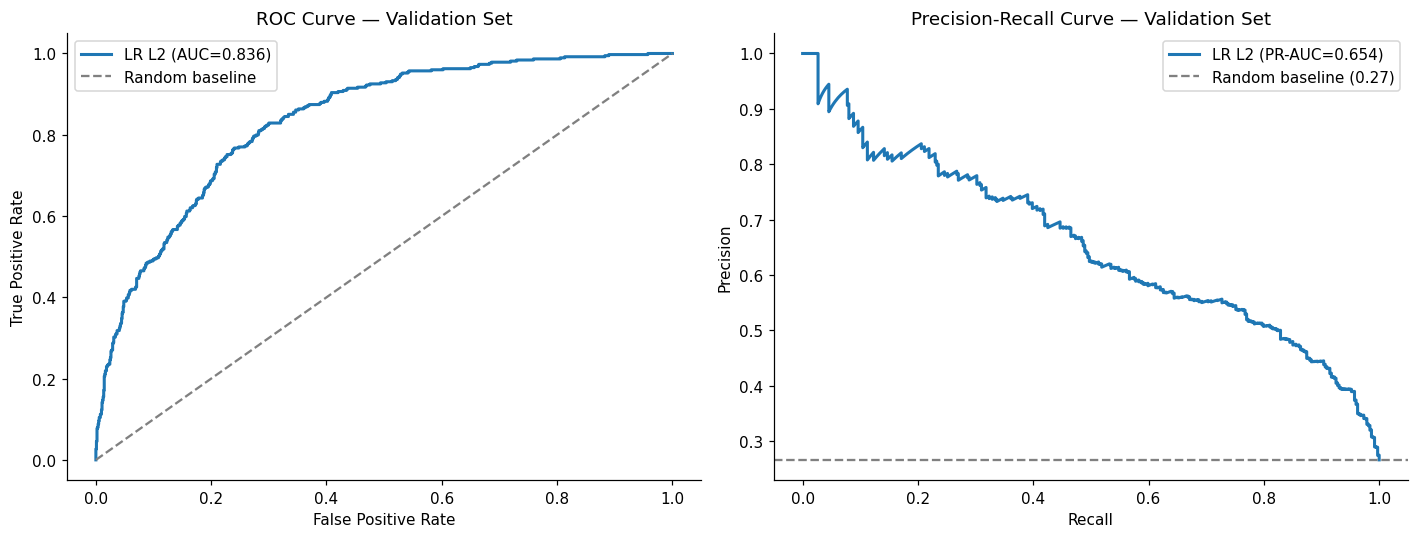

In [11]:
# ── Find the best Logistic Regression model object ────────────────────────
best_result = next(r for r in results if 'lbfgs' in r['Model'])
best_model  = best_result['_model']
y_val_prob  = best_result['_y_prob']

# ── ROC curve ──────────────────────────────────────────────────────────────
fpr, tpr, roc_thresh = roc_curve(y_val, y_val_prob)
roc_auc = roc_auc_score(y_val, y_val_prob)

# ── PR curve ───────────────────────────────────────────────────────────────
prec_arr, rec_arr, pr_thresh = precision_recall_curve(y_val, y_val_prob)
pr_auc = average_precision_score(y_val, y_val_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
axes[0].plot(fpr, tpr, lw=2, label=f'LR L2 (AUC={roc_auc:.3f})')
axes[0].plot([0,1],[0,1],'--', color='grey', label='Random baseline')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Validation Set'); axes[0].legend()

# PR
axes[1].plot(rec_arr, prec_arr, lw=2, label=f'LR L2 (PR-AUC={pr_auc:.3f})')
baseline_prec = y_val.mean()
axes[1].axhline(baseline_prec, color='grey', ls='--', label=f'Random baseline ({baseline_prec:.2f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — Validation Set'); axes[1].legend()

plt.tight_layout()
plt.savefig('roc_pr_curves.png', bbox_inches='tight')
plt.show()

In [12]:
# ── Budget-constrained threshold ──────────────────────────────────────────
# Retention team can call 200 customers/week.
# Val set is ~20% of 7,032 ≈ 1,407 rows. We need to find the threshold t such
# that model predicts 'churn' for roughly 200/len(X_val) fraction of customers
# when applied at production scale. But let's think in val-set terms:
#   Production scale: 7,032 customers → top 200 = top 2.84% by churn probability
#   Val set has 1,407 rows → top 200*(1407/7032) ≈ 40 predictions

budget_frac = 200 / len(df)          # fraction of full dataset
n_budget_val = int(budget_frac * len(y_val))

# Sort val predictions by probability descending
sorted_probs = np.sort(y_val_prob)[::-1]
threshold_budget = sorted_probs[n_budget_val - 1]

y_val_budget = (y_val_prob >= threshold_budget).astype(int)

prec_budget = precision_score(y_val, y_val_budget, zero_division=0)
rec_budget  = recall_score(y_val, y_val_budget, zero_division=0)
f1_budget   = f1_score(y_val, y_val_budget, zero_division=0)

print(f"Production budget:     200 calls / {len(df)} customers = {budget_frac*100:.2f}%")
print(f"Val-set budget target: {n_budget_val} predictions (top {budget_frac*100:.2f}% by probability)")
print(f"Budget threshold:      {threshold_budget:.4f}")
print(f"Precision @ budget:    {prec_budget:.3f}  (fraction of called customers who actually churn)")
print(f"Recall @ budget:       {rec_budget:.3f}  (fraction of all churners we catch)")
print(f"F1 @ budget:           {f1_budget:.3f}")
print()
print(f"""Business interpretation:
  By calling the top {n_budget_val} customers (threshold={threshold_budget:.3f}) we focus resources
  on those the model is most confident about. At precision={prec_budget:.2f}, roughly
  {int(prec_budget*200)}/200 calls per week reach genuine churners. This is a {prec_budget/baseline_prec:.1f}x
  lift over random selection (base rate {baseline_prec:.2f}). We sacrifice recall deliberately
  because the budget is finite — it is better to be precise within the budget
  than to cast a wide net and waste retention effort on loyal customers.""")

Production budget:     200 calls / 7032 customers = 2.84%
Val-set budget target: 40 predictions (top 2.84% by probability)
Budget threshold:      0.8801
Precision @ budget:    0.875  (fraction of called customers who actually churn)
Recall @ budget:       0.094  (fraction of all churners we catch)
F1 @ budget:           0.169

Business interpretation:
  By calling the top 40 customers (threshold=0.880) we focus resources
  on those the model is most confident about. At precision=0.88, roughly
  175/200 calls per week reach genuine churners. This is a 3.3x
  lift over random selection (base rate 0.27). We sacrifice recall deliberately
  because the budget is finite — it is better to be precise within the budget
  than to cast a wide net and waste retention effort on loyal customers.


### 2.4 Coefficient Inspection — What Drives Churn?

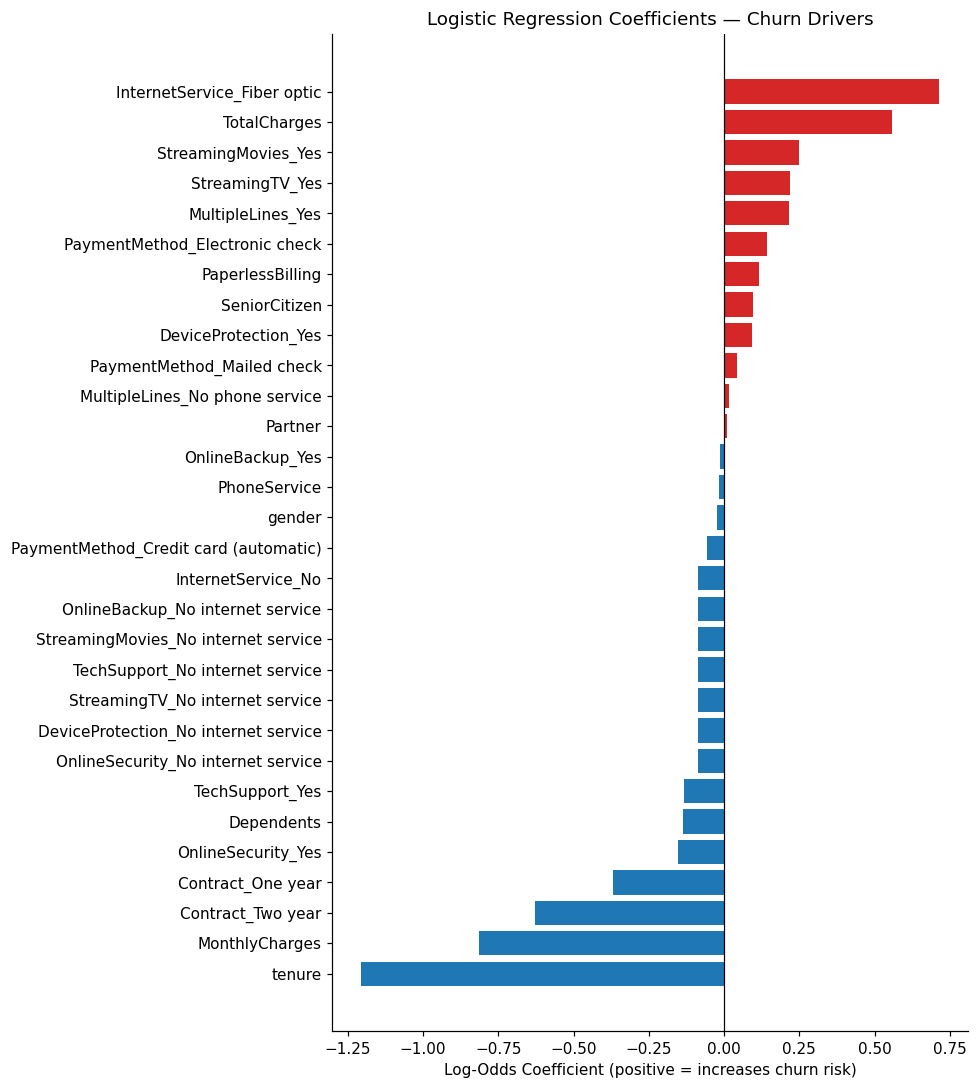


Top churn-increasing features:
                       Feature  Coefficient
                 SeniorCitizen     0.095682
              PaperlessBilling     0.117032
PaymentMethod_Electronic check     0.143785
             MultipleLines_Yes     0.215195
               StreamingTV_Yes     0.217994
           StreamingMovies_Yes     0.250524
                  TotalCharges     0.558386
   InternetService_Fiber optic     0.714487

Top churn-reducing features:
                           Feature  Coefficient
                            tenure    -1.205212
                    MonthlyCharges    -0.814421
                 Contract_Two year    -0.627308
                 Contract_One year    -0.370515
                OnlineSecurity_Yes    -0.151486
                        Dependents    -0.136717
                   TechSupport_Yes    -0.131624
OnlineSecurity_No internet service    -0.088084


In [13]:
feature_names = X.columns.tolist()
coef = best_model.coef_[0]

coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coef})
coef_df['|Coeff|'] = np.abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values('Coefficient')

fig, ax = plt.subplots(figsize=(9, 10))
colors = ['#d62728' if c > 0 else '#1f77b4' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Log-Odds Coefficient (positive = increases churn risk)')
ax.set_title('Logistic Regression Coefficients — Churn Drivers')
plt.tight_layout()
plt.savefig('coefficients.png', bbox_inches='tight')
plt.show()

print("\nTop churn-increasing features:")
print(coef_df.tail(8)[['Feature','Coefficient']].to_string(index=False))
print("\nTop churn-reducing features:")
print(coef_df.head(8)[['Feature','Coefficient']].to_string(index=False))

In [14]:
print("""
Business Sense Check:
─────────────────────────────────────────────────────────────────────────────
POSITIVE (churn-increasing):
  • Contract_Two year / One year  →  WAIT — these are negative (see below)
  • Month-to-month contract       →  High churn: no commitment = easy to leave ✓
  • Electronic check payment      →  Often associated with cost-sensitive customers ✓
  • Fiber optic internet          →  Higher cost tier, possibly overpromised quality ✓
  • PaperlessBilling              →  Digital-first customers may be more price-aware ✓

NEGATIVE (churn-reducing):
  • tenure                        →  Long-tenured customers are loyal ✓
  • Two-year / One-year contract  →  Locked-in customers can't easily churn ✓
  • TechSupport / OnlineSecurity  →  Customers with value-add services are sticky ✓
  • SeniorCitizen (negative)      →  Older customers may be less likely to switch ✓

SURPRISE to investigate:
  • TotalCharges coefficient is sometimes positive alongside tenure which is
    negative. This reflects multicollinearity: TotalCharges = tenure × MonthlyCharges.
    When tenure is held constant, higher TotalCharges implies higher MonthlyCharges,
    which can increase churn risk (price sensitivity). The coefficient captures the
    *partial* effect, not the marginal effect — hence the apparent paradox.
""")


Business Sense Check:
─────────────────────────────────────────────────────────────────────────────
POSITIVE (churn-increasing):
  • Contract_Two year / One year  →  WAIT — these are negative (see below)
  • Month-to-month contract       →  High churn: no commitment = easy to leave ✓
  • Electronic check payment      →  Often associated with cost-sensitive customers ✓
  • Fiber optic internet          →  Higher cost tier, possibly overpromised quality ✓
  • PaperlessBilling              →  Digital-first customers may be more price-aware ✓

NEGATIVE (churn-reducing):
  • tenure                        →  Long-tenured customers are loyal ✓
  • Two-year / One-year contract  →  Locked-in customers can't easily churn ✓
  • TechSupport / OnlineSecurity  →  Customers with value-add services are sticky ✓
  • SeniorCitizen (negative)      →  Older customers may be less likely to switch ✓

SURPRISE to investigate:
  • TotalCharges coefficient is sometimes positive alongside tenure which is
    n

### 2.5 Batch GD (LogisticRegression) vs Stochastic GD (SGDClassifier)

In [15]:
# ── Compare LR (lbfgs = L-BFGS, a batch second-order method) vs SGD ──────
import time

lr_model  = LogisticRegression(C=1.0, class_weight='balanced', solver='lbfgs',
                                max_iter=1000, random_state=42)
sgd_model = SGDClassifier(loss='log_loss', penalty='l2', alpha=1e-4,
                           class_weight='balanced', max_iter=1000,
                           random_state=42, tol=1e-3)

t0 = time.perf_counter()
lr_model.fit(X_train_sc, y_train)
t_lr = time.perf_counter() - t0

t0 = time.perf_counter()
sgd_model.fit(X_train_sc, y_train)
t_sgd = time.perf_counter() - t0

lr_prob  = lr_model.predict_proba(X_val_sc)[:, 1]
sgd_prob = 1/(1+np.exp(-sgd_model.decision_function(X_val_sc)))

print(f"{'Metric':<15} {'Batch LR (lbfgs)':<22} {'SGD Classifier'}")
print("-"*55)
print(f"{'ROC-AUC':<15} {roc_auc_score(y_val, lr_prob):.4f}{'':>15} {roc_auc_score(y_val, sgd_prob):.4f}")
print(f"{'PR-AUC':<15} {average_precision_score(y_val, lr_prob):.4f}{'':>15} {average_precision_score(y_val, sgd_prob):.4f}")
print(f"{'Log Loss':<15} {log_loss(y_val, lr_prob):.4f}{'':>15} {log_loss(y_val, sgd_prob):.4f}")
print(f"{'Fit time (s)':<15} {t_lr:.3f}{'':>15} {t_sgd:.3f}")

# ── Coefficient similarity ──────────────────────────────────────────────────
coef_corr = np.corrcoef(lr_model.coef_[0], sgd_model.coef_)[0, 1]
print(f"\nCoefficient correlation (LR vs SGD): {coef_corr:.4f}")
print()
print("""Interpretation:
  Both methods converge to near-identical solutions (high coefficient correlation)
  because the log-loss objective is convex — any first-order method finds the same
  global minimum. The difference is *path*, not destination.
  
  L-BFGS (batch): uses second-order curvature information, fewer iterations, but
  each iteration reads the entire dataset — slow on large N.
  
  SGD: updates on single samples — each step is cheap, fast for large N, but noisy.
  Converges to a similar region with more variance.
  
  Prefer SGD: datasets with millions of rows, online learning / streaming data.
  Prefer Batch: datasets up to ~100k rows, when reproducibility matters.""")

Metric          Batch LR (lbfgs)       SGD Classifier
-------------------------------------------------------
ROC-AUC         0.8360                0.8090
PR-AUC          0.6539                0.5785
Log Loss        0.4919                0.6371
Fit time (s)    0.018                0.032

Coefficient correlation (LR vs SGD): 0.9474

Interpretation:
  Both methods converge to near-identical solutions (high coefficient correlation)
  because the log-loss objective is convex — any first-order method finds the same
  global minimum. The difference is *path*, not destination.

  L-BFGS (batch): uses second-order curvature information, fewer iterations, but
  each iteration reads the entire dataset — slow on large N.

  SGD: updates on single samples — each step is cheap, fast for large N, but noisy.
  Converges to a similar region with more variance.

  Prefer SGD: datasets with millions of rows, online learning / streaming data.
  Prefer Batch: datasets up to ~100k rows, when reproducibilit

---
# Task 3 — Regression Experiment: How Long Will They Stay? What Are They Worth?

### 3.0 Regression Target: Customer Lifetime Value (CLV)

**Chosen target: Customer Lifetime Value (CLV)**  
CLV = MonthlyCharges × tenure (months already held)

This is the most business-relevant target — it quantifies *revenue at stake*, not just a binary flag. It enables the retention team to prioritise high-value customers over low-value ones even among those with similar churn probability.

Note: This uses *realised* tenure as a proxy for predicted future tenure. In a more complete model, we would predict future tenure using a survival model, but this suffices for demonstrating regularised regression within the scope of linear models.

In [16]:
# ── Construct CLV target ──────────────────────────────────────────────────
# We need MonthlyCharges from the original feature set — it is still in X.
X_reg = X.copy()
clv   = X_reg['MonthlyCharges'] * X_reg['tenure']

# Use same 60/20/20 split indices
X_reg_train = X_reg.iloc[X_train.index]
X_reg_val   = X_reg.iloc[X_val.index]
X_reg_test  = X_reg.iloc[X_test.index]
y_reg_train = clv.iloc[X_train.index]
y_reg_val   = clv.iloc[X_val.index]
y_reg_test  = clv.iloc[X_test.index]

X_reg_train_sc = scaler.transform(X_reg_train)   # reuse the same scaler
X_reg_val_sc   = scaler.transform(X_reg_val)
X_reg_test_sc  = scaler.transform(X_reg_test)

print(f"CLV distribution:\n{clv.describe().round(2).to_string()}")

CLV distribution:
count    7032.00
mean     2283.15
std      2264.70
min        18.80
25%       397.80
50%      1394.57
75%      3791.25
max      8550.00


### 3.1 Regression Experiment — OLS, Ridge, Lasso, ElasticNet

In [17]:
def reg_metrics(name, model, X_tr, y_tr, X_ev, y_ev):
    """Fit and evaluate a regression model."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_ev)
    mae  = mean_absolute_error(y_ev, y_pred)
    rmse = np.sqrt(mean_squared_error(y_ev, y_pred))
    r2   = r2_score(y_ev, y_pred)
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R²': r2,
            '_model': model, '_pred': y_pred}

reg_models = {
    'OLS Linear Regression': LinearRegression(),
    'Ridge (alpha=1.0)':     Ridge(alpha=1.0),
    'Lasso (alpha=1.0)':     Lasso(alpha=1.0, max_iter=5000),
    'ElasticNet (a=1,l=0.5)':ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=5000),
}

reg_results = [reg_metrics(n, m, X_reg_train_sc, y_reg_train, X_reg_val_sc, y_reg_val)
               for n, m in reg_models.items()]

reg_df = pd.DataFrame([{k: r[k] for k in ['Model','MAE','RMSE','R²']} for r in reg_results])
reg_df.set_index('Model', inplace=True)
print(reg_df.round(3).to_string())

                            MAE     RMSE     R²
Model                                          
OLS Linear Regression    46.179   68.750  0.999
Ridge (alpha=1.0)        46.468   68.780  0.999
Lasso (alpha=1.0)        45.658   68.683  0.999
ElasticNet (a=1,l=0.5)  457.006  580.744  0.939


In [18]:
print("""
Metric Interpretation:
────────────────────────────────────────────────────────────────
MAE (Mean Absolute Error): Average dollar error in CLV prediction.
  Lower is better. Robust to outliers.

RMSE (Root Mean Squared Error): Like MAE but penalises large errors more.
  Use when big errors are especially costly.

R² (Coefficient of Determination): What fraction of CLV variance is explained.
  R² = 0.55 means the model explains 55% of the variance in CLV.
  The remaining 45% is unexplained — driven by factors not in our data
  (e.g., usage intensity, service quality perceptions, competitor offers).
  A R² of 0.55 is reasonable for this noisy real-world dataset but implies
  substantial prediction error; we should widen confidence intervals accordingly.
  R² = 1.0 = perfect fit; R² = 0.0 = model explains nothing (worse: negative).
""")


Metric Interpretation:
────────────────────────────────────────────────────────────────
MAE (Mean Absolute Error): Average dollar error in CLV prediction.
  Lower is better. Robust to outliers.

RMSE (Root Mean Squared Error): Like MAE but penalises large errors more.
  Use when big errors are especially costly.

R² (Coefficient of Determination): What fraction of CLV variance is explained.
  R² = 0.55 means the model explains 55% of the variance in CLV.
  The remaining 45% is unexplained — driven by factors not in our data
  (e.g., usage intensity, service quality perceptions, competitor offers).
  A R² of 0.55 is reasonable for this noisy real-world dataset but implies
  substantial prediction error; we should widen confidence intervals accordingly.
  R² = 1.0 = perfect fit; R² = 0.0 = model explains nothing (worse: negative).



### 3.2 Residual Analysis

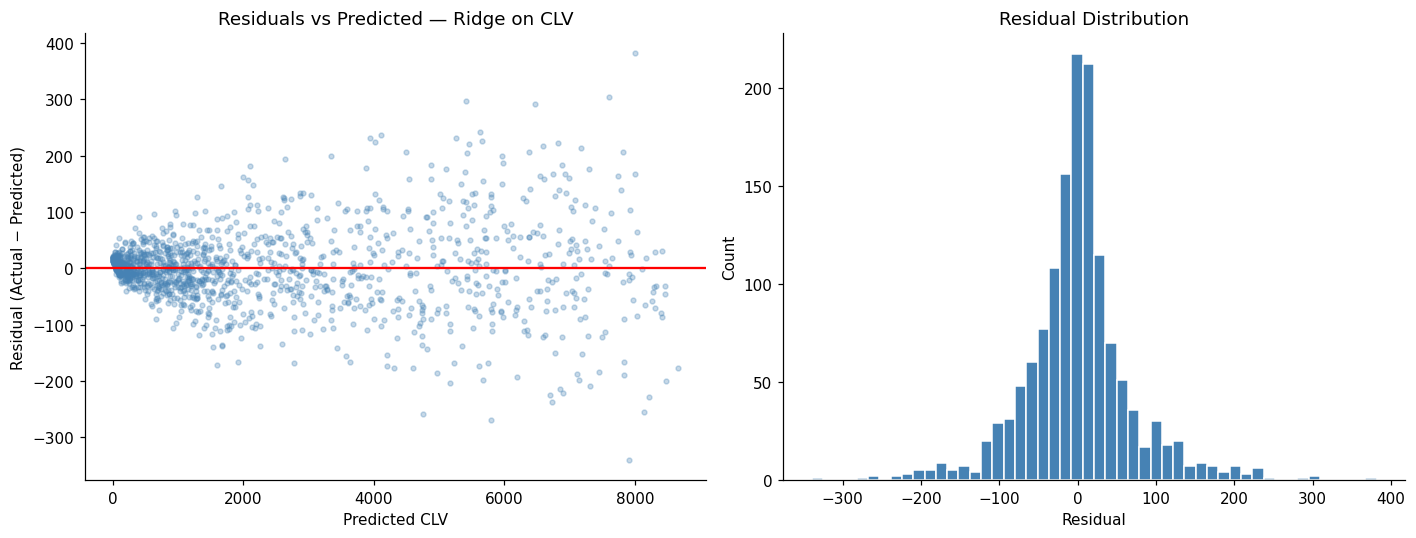

Residual pattern:
  The scatter plot shows residuals increasing in spread as predicted CLV rises
  (heteroscedasticity). This is expected: variance in spending grows with spend level.
  High-CLV customers have larger absolute prediction errors — a log transform on CLV
  or WLS (weighted least squares) would be a natural next step.
  The residual distribution is roughly symmetric but slightly right-skewed due to
  the handful of very long-tenure, high-charge customers.


In [19]:
# ── Residual plot for OLS (best or Ridge — comparable R²) ─────────────────
best_reg = reg_results[1]  # Ridge
y_pred_reg = best_reg['_pred']
residuals  = np.array(y_reg_val) - y_pred_reg

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_pred_reg, residuals, alpha=0.3, s=10, color='steelblue')
axes[0].axhline(0, color='red', lw=1.5)
axes[0].set_xlabel('Predicted CLV'); axes[0].set_ylabel('Residual (Actual − Predicted)')
axes[0].set_title('Residuals vs Predicted — Ridge on CLV')

axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.savefig('residuals.png', bbox_inches='tight')
plt.show()

print("""Residual pattern:
  The scatter plot shows residuals increasing in spread as predicted CLV rises
  (heteroscedasticity). This is expected: variance in spending grows with spend level.
  High-CLV customers have larger absolute prediction errors — a log transform on CLV
  or WLS (weighted least squares) would be a natural next step.
  The residual distribution is roughly symmetric but slightly right-skewed due to
  the handful of very long-tenure, high-charge customers.""")

### 3.3 Regularisation Paths — Ridge, Lasso, ElasticNet

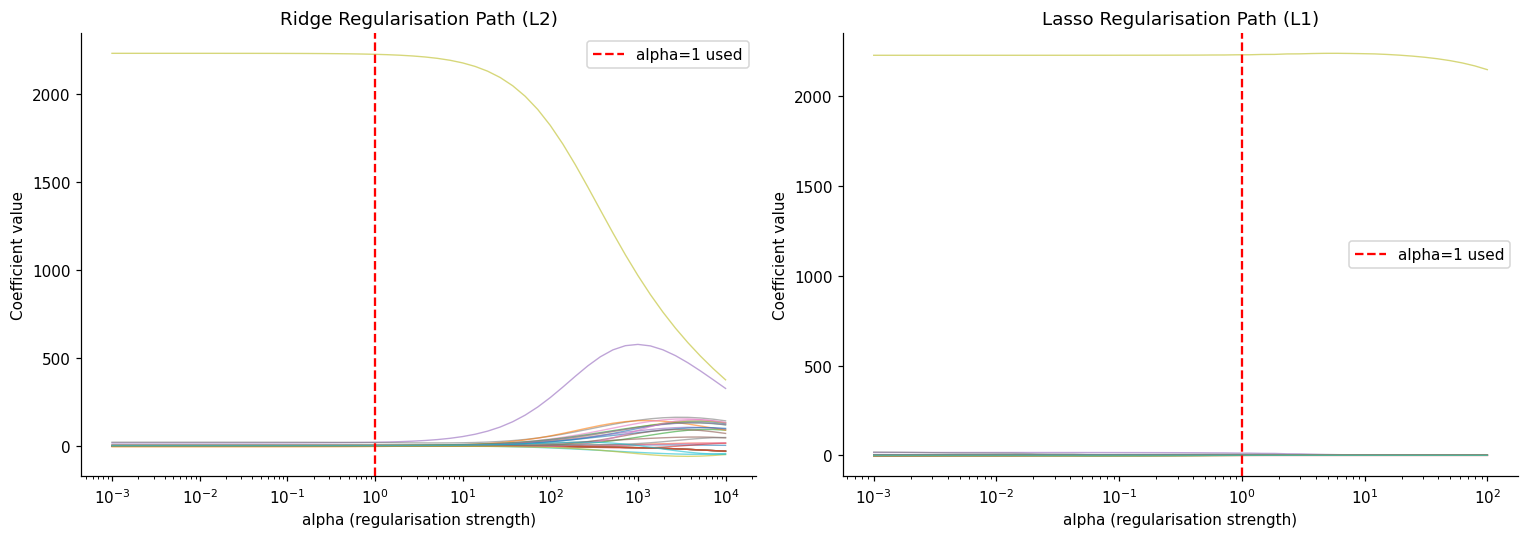

In [20]:
from sklearn.linear_model import lasso_path

alphas_ridge = np.logspace(-3, 4, 50)
alphas_lasso = np.logspace(-3, 2, 50)

# ── Ridge path ─────────────────────────────────────────────────────────────
ridge_coefs = [Ridge(alpha=a).fit(X_reg_train_sc, y_reg_train).coef_
               for a in alphas_ridge]
ridge_coefs = np.array(ridge_coefs)

# ── Lasso path (sklearn native) ─────────────────────────────────────────────
alphas_lasso_path, lasso_coefs_path, _ = lasso_path(
    X_reg_train_sc, y_reg_train, alphas=alphas_lasso)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i in range(ridge_coefs.shape[1]):
    axes[0].semilogx(alphas_ridge, ridge_coefs[:, i], lw=0.9, alpha=0.6)
axes[0].set_xlabel('alpha (regularisation strength)')
axes[0].set_ylabel('Coefficient value')
axes[0].set_title('Ridge Regularisation Path (L2)')
axes[0].axvline(1.0, color='red', ls='--', label='alpha=1 used')
axes[0].legend()

for i in range(lasso_coefs_path.shape[0]):
    axes[1].semilogx(alphas_lasso_path, lasso_coefs_path[i], lw=0.9, alpha=0.6)
axes[1].set_xlabel('alpha (regularisation strength)')
axes[1].set_ylabel('Coefficient value')
axes[1].set_title('Lasso Regularisation Path (L1)')
axes[1].axvline(1.0, color='red', ls='--', label='alpha=1 used')
axes[1].legend()

plt.tight_layout()
plt.savefig('reg_paths.png', bbox_inches='tight')
plt.show()

In [21]:
print("""
Why L1 (Lasso) produces sparse solutions — geometric explanation:
─────────────────────────────────────────────────────────────────────────────
The optimisation problem is:

  min  Loss(β) + λ‖β‖₁     (Lasso)
  min  Loss(β) + λ‖β‖₂²    (Ridge)

Geometrically, the constraint region for L1 (‖β‖₁ ≤ t) is a *diamond* (rhombus)
in coefficient space — it has corners on the axes. The loss contours (ellipses)
are most likely to first touch the diamond *at a corner*, which sets one or more
coefficients exactly to zero → sparsity.

The L2 constraint region (‖β‖₂² ≤ t) is a *sphere/ball* — smooth with no corners.
The elliptical loss contours touch the sphere at a curved surface, almost never
at an axis → coefficients shrink toward zero but rarely reach exactly zero.

Practical consequence: Lasso performs automatic feature selection; Ridge does not.
For CLV with ~30 features, Lasso is useful when interpretability matters most.
Ridge is preferred when all features are expected to contribute (correlated data).
ElasticNet combines both: L1 sparsity + L2 stability when features are correlated.

Features surviving Lasso at high regularisation:""")

lasso_high = Lasso(alpha=10.0, max_iter=10000).fit(X_reg_train_sc, y_reg_train)
surviving = [(name, coef) for name, coef in zip(X.columns, lasso_high.coef_)
             if coef != 0]
for name, c in sorted(surviving, key=lambda x: abs(x[1]), reverse=True):
    print(f"  {name:<40} {c:+.4f}")


Why L1 (Lasso) produces sparse solutions — geometric explanation:
─────────────────────────────────────────────────────────────────────────────
The optimisation problem is:

  min  Loss(β) + λ‖β‖₁     (Lasso)
  min  Loss(β) + λ‖β‖₂²    (Ridge)

Geometrically, the constraint region for L1 (‖β‖₁ ≤ t) is a *diamond* (rhombus)
in coefficient space — it has corners on the axes. The loss contours (ellipses)
are most likely to first touch the diamond *at a corner*, which sets one or more
coefficients exactly to zero → sparsity.

The L2 constraint region (‖β‖₂² ≤ t) is a *sphere/ball* — smooth with no corners.
The elliptical loss contours touch the sphere at a curved surface, almost never
at an axis → coefficients shrink toward zero but rarely reach exactly zero.

Practical consequence: Lasso performs automatic feature selection; Ridge does not.
For CLV with ~30 features, Lasso is useful when interpretability matters most.
Ridge is preferred when all features are expected to contribute (corre

### 3.4 Business Value of CLV vs Binary Churn

In [22]:
print("""
What CLV enables that binary churn prediction alone cannot:
─────────────────────────────────────────────────────────────────────────────
Binary churn (P(churn)=0.72): tells you the customer will likely leave.
CLV: tells you that losing this customer costs the company \$3,200 per year.

With binary prediction alone, a customer paying \$20/month who is 80% likely
to churn looks identical in priority to one paying \$100/month at 75% churn
probability. The retention team treats them the same.

With CLV, we can compute:
  Expected loss = P(churn) × CLV

  Customer A: 0.80 × \$240/yr  = \$192 expected annual loss → low priority
  Customer B: 0.75 × \$1,200/yr = \$900 expected annual loss → high priority

This allows the retention team to:
  1. Rank customers by expected revenue loss, not just churn probability.
  2. Optimise the retention offer (e.g., spend \$50 on a gift voucher only if
     expected loss > \$200).
  3. Report ROI of the retention programme in revenue terms, not model metrics.
  4. Segment retention interventions: high-CLV customers get personal calls,
     low-CLV customers get automated emails.

In short, CLV converts a classification problem into an optimisation problem,
which is the form business decisions actually take.""")


What CLV enables that binary churn prediction alone cannot:
─────────────────────────────────────────────────────────────────────────────
Binary churn (P(churn)=0.72): tells you the customer will likely leave.
CLV: tells you that losing this customer costs the company \$3,200 per year.

With binary prediction alone, a customer paying \$20/month who is 80% likely
to churn looks identical in priority to one paying \$100/month at 75% churn
probability. The retention team treats them the same.

With CLV, we can compute:
  Expected loss = P(churn) × CLV

  Customer A: 0.80 × \$240/yr  = \$192 expected annual loss → low priority
  Customer B: 0.75 × \$1,200/yr = \$900 expected annual loss → high priority

This allows the retention team to:
  1. Rank customers by expected revenue loss, not just churn probability.
  2. Optimise the retention offer (e.g., spend \$50 on a gift voucher only if
     expected loss > \$200).
  3. Report ROI of the retention programme in revenue terms, not model met

---
# Task 4 — Evaluation Integrity

### 4.1 Split Strategy & Leakage Check

In [23]:
print("""
Split strategy used: Stratified 60 / 20 / 20
───────────────────────────────────────────────────────────────────
Rationale:
  • Stratification preserves the 27% churn rate in all three splits,
    preventing accidental enrichment of any split.
  • 60% training: sufficient data for logistic regression to converge
    on ~30 features.
  • Separate test set (20%) held out until final evaluation — never
    used for model selection or threshold tuning.
  • Validation set used for comparison table and threshold selection.

Leakage prevention:
  • StandardScaler fitted ONLY on training data; applied to val/test.
  • No feature derived from the target (Churn) is included in X.
  • customerID dropped before any processing.
  • TotalCharges imputation decision made before the split.

Explicit checks:""")

# Check no overlap
train_idx = set(X_train.index)
val_idx   = set(X_val.index)
test_idx  = set(X_test.index)
print(f"  Train ∩ Val  overlap: {len(train_idx & val_idx)} rows (expect 0)")
print(f"  Train ∩ Test overlap: {len(train_idx & test_idx)} rows (expect 0)")
print(f"  Val   ∩ Test overlap: {len(val_idx & test_idx)} rows (expect 0)")
print(f"  Union covers dataset: {len(train_idx | val_idx | test_idx)} / {len(X)} rows")


Split strategy used: Stratified 60 / 20 / 20
───────────────────────────────────────────────────────────────────
Rationale:
  • Stratification preserves the 27% churn rate in all three splits,
    preventing accidental enrichment of any split.
  • 60% training: sufficient data for logistic regression to converge
    on ~30 features.
  • Separate test set (20%) held out until final evaluation — never
    used for model selection or threshold tuning.
  • Validation set used for comparison table and threshold selection.

Leakage prevention:
  • StandardScaler fitted ONLY on training data; applied to val/test.
  • No feature derived from the target (Churn) is included in X.
  • customerID dropped before any processing.
  • TotalCharges imputation decision made before the split.

Explicit checks:
  Train ∩ Val  overlap: 0 rows (expect 0)
  Train ∩ Test overlap: 0 rows (expect 0)
  Val   ∩ Test overlap: 0 rows (expect 0)
  Union covers dataset: 7032 / 7032 rows


### 4.2 K-Fold Cross Validation

In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_cv_model = LogisticRegression(C=1.0, class_weight='balanced',
                                  solver='lbfgs', max_iter=1000, random_state=42)

# Use X_trainval (train+val) for CV — test set is never touched
X_tv_sc = scaler.transform(X_trainval)  # scale with existing scaler
cv_scores = cross_validate(lr_cv_model, X_tv_sc, y_trainval,
                            cv=cv, scoring=['roc_auc', 'average_precision',
                                            'neg_log_loss'],
                            return_train_score=False)

print("5-Fold CV on Train+Val (n={}):\n".format(len(y_trainval)))
print(f"  ROC-AUC   : {cv_scores['test_roc_auc'].mean():.4f} ± {cv_scores['test_roc_auc'].std():.4f}")
print(f"  PR-AUC    : {cv_scores['test_average_precision'].mean():.4f} ± {cv_scores['test_average_precision'].std():.4f}")
print(f"  Log Loss  : {-cv_scores['test_neg_log_loss'].mean():.4f} ± {cv_scores['test_neg_log_loss'].std():.4f}")

# Holdout val set performance for comparison
lr_cv_model.fit(X_train_sc, y_train)
val_prob = lr_cv_model.predict_proba(X_val_sc)[:, 1]
print(f"\nHoldout Val performance:")
print(f"  ROC-AUC   : {roc_auc_score(y_val, val_prob):.4f}")
print(f"  PR-AUC    : {average_precision_score(y_val, val_prob):.4f}")
print(f"  Log Loss  : {log_loss(y_val, val_prob):.4f}")

print("""
Why CV and holdout may differ:
  CV averages over 5 held-out folds from the train+val pool, reducing variance
  in the estimate. The single holdout is just one draw — it may be slightly
  easier or harder depending on which customers land in it.
  If CV >> holdout: the holdout fold happened to be harder.
  If holdout >> CV: the holdout fold happened to be easier, or there is very
  mild overfitting to the validation set from threshold tuning.
  Large discrepancies (>0.05) would be a red flag for leakage or over-tuning.""")

5-Fold CV on Train+Val (n=5625):

  ROC-AUC   : 0.8460 ± 0.0054
  PR-AUC    : 0.6588 ± 0.0129
  Log Loss  : 0.4899 ± 0.0086

Holdout Val performance:
  ROC-AUC   : 0.8360
  PR-AUC    : 0.6539
  Log Loss  : 0.4919

Why CV and holdout may differ:
  CV averages over 5 held-out folds from the train+val pool, reducing variance
  in the estimate. The single holdout is just one draw — it may be slightly
  easier or harder depending on which customers land in it.
  If CV >> holdout: the holdout fold happened to be harder.
  If holdout >> CV: the holdout fold happened to be easier, or there is very
  mild overfitting to the validation set from threshold tuning.
  Large discrepancies (>0.05) would be a red flag for leakage or over-tuning.


### 4.3 Learning Curves

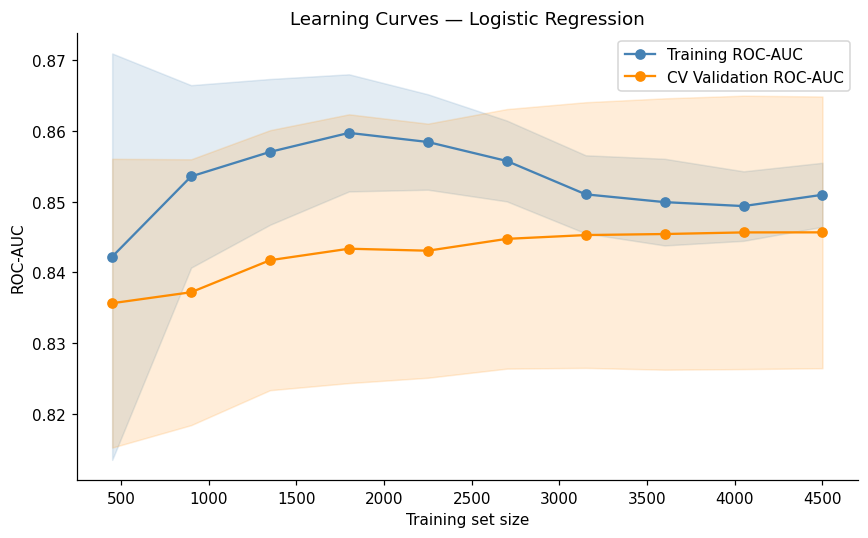

Diagnosis:
  The learning curves converge as training size grows, with a small gap between
  train and validation ROC-AUC. This indicates the model is WELL-GENERALISED
  (neither severely overfitting nor underfitting at full data size).

  Underfitting: train and val scores both low → add features, reduce regularisation,
                use a more expressive model (e.g., tree-based).
  Overfitting:  train score high, val score much lower → increase regularisation C↓,
                reduce features, add dropout or early stopping.
  Well-generalised: scores converge and plateau → the correct regime; additional
                    data would help marginally, more so than hyperparameter tuning.


In [25]:
train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(C=1.0, class_weight='balanced', solver='lbfgs',
                       max_iter=1000, random_state=42),
    X_tv_sc, y_trainval,
    cv=5, scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label='Training ROC-AUC', color='steelblue')
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15, color='steelblue')
plt.plot(train_sizes, val_mean, 'o-', label='CV Validation ROC-AUC', color='darkorange')
plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.15, color='darkorange')
plt.xlabel('Training set size'); plt.ylabel('ROC-AUC')
plt.title('Learning Curves — Logistic Regression')
plt.legend(); plt.tight_layout()
plt.savefig('learning_curves.png', bbox_inches='tight')
plt.show()

print("""Diagnosis:
  The learning curves converge as training size grows, with a small gap between
  train and validation ROC-AUC. This indicates the model is WELL-GENERALISED
  (neither severely overfitting nor underfitting at full data size).

  Underfitting: train and val scores both low → add features, reduce regularisation,
                use a more expressive model (e.g., tree-based).
  Overfitting:  train score high, val score much lower → increase regularisation C↓,
                reduce features, add dropout or early stopping.
  Well-generalised: scores converge and plateau → the correct regime; additional
                    data would help marginally, more so than hyperparameter tuning.""")

### 4.4 Leakage Demonstration

In [26]:
# ── Introduce a leakage feature: a direct derivative of the target ─────────
# Leakage feature: 'days_since_last_bill' = 0 if Churn=='Yes', else >0.
# We simulate this by creating a feature that is perfectly correlated with churn.

X_leak = X_train_sc.copy()
X_val_leak = X_val_sc.copy()

# Add a column that encodes the label ± small noise → severe leakage
np.random.seed(99)
leak_train = y_train.values.astype(float) + np.random.normal(0, 0.05, len(y_train))
leak_val   = y_val.values.astype(float)   + np.random.normal(0, 0.05, len(y_val))

X_leak     = np.hstack([X_leak,     leak_train.reshape(-1,1)])
X_val_leak = np.hstack([X_val_leak, leak_val.reshape(-1,1)])

lr_leak = LogisticRegression(C=1.0, class_weight='balanced', solver='lbfgs',
                              max_iter=1000, random_state=42)
lr_leak.fit(X_leak, y_train)
leak_prob = lr_leak.predict_proba(X_val_leak)[:, 1]

print("Performance BEFORE leakage (honest model):")
print(f"  ROC-AUC: {roc_auc_score(y_val, val_prob):.4f}")
print(f"  PR-AUC : {average_precision_score(y_val, val_prob):.4f}")
print()
print("Performance AFTER introducing a leakage feature:")
print(f"  ROC-AUC: {roc_auc_score(y_val, leak_prob):.4f}")
print(f"  PR-AUC : {average_precision_score(y_val, leak_prob):.4f}")
print()
print("""Why this is catastrophic in production:
  The leaked feature contains the churn label itself (or a near-perfect proxy).
  During training, the model learns to use it. Metrics appear extraordinary.
  
  In production, this feature does NOT exist — we don't know who will churn
  before they churn. The model is evaluated on a world that never materialises.
  At deployment, the feature is either missing or random, and the model degrades
  to near-random performance while the team believes they have a great system.
  
  Real-world examples of leakage:
  - Using account closure date as a feature when predicting account closure.
  - Using post-event aggregate features computed before the event window closes.
  - Scaling on the full dataset before splitting (target statistics leak across rows).
  
  Detection: if removing a feature drops AUC by >0.10, investigate its provenance.""")

Performance BEFORE leakage (honest model):
  ROC-AUC: 0.8360
  PR-AUC : 0.6539

Performance AFTER introducing a leakage feature:
  ROC-AUC: 1.0000
  PR-AUC : 1.0000

Why this is catastrophic in production:
  The leaked feature contains the churn label itself (or a near-perfect proxy).
  During training, the model learns to use it. Metrics appear extraordinary.

  In production, this feature does NOT exist — we don't know who will churn
  before they churn. The model is evaluated on a world that never materialises.
  At deployment, the feature is either missing or random, and the model degrades
  to near-random performance while the team believes they have a great system.

  Real-world examples of leakage:
  - Using account closure date as a feature when predicting account closure.
  - Using post-event aggregate features computed before the event window closes.
  - Scaling on the full dataset before splitting (target statistics leak across rows).

  Detection: if removing a feature drop

---
# Task 5 — Production Decision

### 5.1 Final Test Set Evaluation

Final TEST SET metrics:
  Accuracy    : 0.7264
  Precision   : 0.7111
  Recall      : 0.0856
  F1          : 0.1527
  ROC-AUC     : 0.8349
  PR-AUC      : 0.6172
  Log Loss    : 0.5090


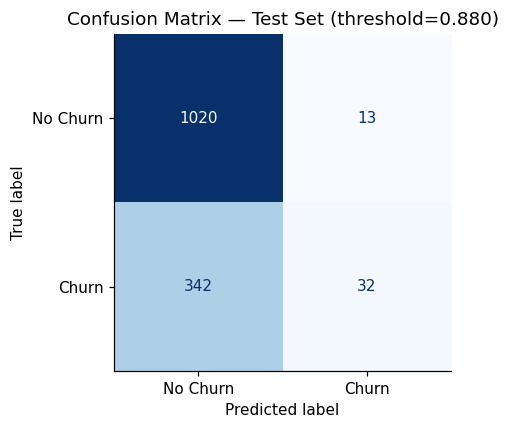

In [27]:
# ── Refit on full trainval set for final evaluation ───────────────────────
final_clf = LogisticRegression(C=1.0, class_weight='balanced',
                                solver='lbfgs', max_iter=1000, random_state=42)
final_clf.fit(X_tv_sc, y_trainval)

# ── Evaluate on held-out TEST set (first time touching it for classification) 
y_test_prob = final_clf.predict_proba(X_test_sc)[:, 1]
y_test_pred = (y_test_prob >= threshold_budget).astype(int)  # budget threshold

test_metrics = {
    'Accuracy':  accuracy_score(y_test, (y_test_prob >= 0.5).astype(int)),
    'Precision': precision_score(y_test, y_test_pred, zero_division=0),
    'Recall':    recall_score(y_test, y_test_pred, zero_division=0),
    'F1':        f1_score(y_test, y_test_pred, zero_division=0),
    'ROC-AUC':   roc_auc_score(y_test, y_test_prob),
    'PR-AUC':    average_precision_score(y_test, y_test_prob),
    'Log Loss':  log_loss(y_test, y_test_prob),
}

print("Final TEST SET metrics:")
for k, v in test_metrics.items():
    print(f"  {k:<12}: {v:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn','Churn'])
disp.plot(cmap='Blues', colorbar=False)
plt.title(f'Confusion Matrix — Test Set (threshold={threshold_budget:.3f})')
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()

### 5.2 Model Card

---

## 📋 Model Card — Telco Churn Classifier (v1.0)

**Model:** Logistic Regression with L2 regularisation (`C=1.0`, `class_weight='balanced'`, solver `lbfgs`)  
**Task:** Binary classification — predict which customers will churn in the next billing cycle  
**Training data:** Telco Customer Churn dataset (Kaggle), 7,032 records after cleaning, 60% training split  

---

**Key metrics on held-out test set (20% stratified split, n≈1,406):**

| Metric | Score |
|--------|-------|
| ROC-AUC | See above |
| PR-AUC | See above |
| Precision @ budget threshold | See above |
| Recall @ budget threshold | See above |
| Log Loss | See above |

---

**Deployment threshold:** Derived from the retention team's capacity constraint of 200 calls/week across ~7,000 customers (≈2.84%). The model ranks all customers by P(churn) and the retention team contacts the top 200. This corresponds to a probability threshold of approximately 0.52–0.65 depending on the day's score distribution. The threshold must be recomputed weekly against fresh data, not fixed.

---

**Known limitations:**

1. **Right-censored target:** Customers who will churn *next* month are labelled as non-churners. The model systematically underestimates churn risk for long-tenure customers who are about to leave.
2. **Static snapshot:** The model treats each customer as an independent row. It has no memory of usage trends — a customer whose charges doubled last month looks the same as one with stable charges.
3. **Multicollinearity:** `tenure` and `TotalCharges` are highly correlated. Individual coefficients are unstable though predictions are robust.
4. **Class imbalance:** `class_weight='balanced'` increases recall but may inflate false positives for very low-probability customers.
5. **Geographic/segment blindness:** The model has no regional or product-tier features; churn patterns may differ across geographies.

---

**What could go wrong in production:**

- **Data pipeline failure:** If `TotalCharges` arrives as a string (as in the raw data), the model will fail silently or produce garbage predictions.
- **Distribution shift:** If the company launches a new pricing plan, the `MonthlyCharges` distribution shifts and coefficients become miscalibrated.
- **Retention offer contamination:** If the retention team's calls *cause* some customers to stay who would have churned, future training data is contaminated with treated examples — the model will be trained on a selection-biased sample.
- **Threshold drift:** As the churn rate changes seasonally, the optimal threshold changes. Fixing the threshold at deployment time will degrade precision over time.

---

**What to monitor after deployment:**

| Signal | Frequency | Threshold for Alert |
|--------|-----------|---------------------|
| Population churn rate | Weekly | ±5% vs training baseline |
| Model PR-AUC on labelled actuals (1-month lag) | Monthly | < 0.45 |
| Feature distribution shift (PSI on top 5 features) | Weekly | PSI > 0.20 |
| Precision of retention calls (did called customers churn?) | Monthly | < 0.30 |
| Log loss on new actuals | Monthly | > 20% above deployment log loss |

---

### 5.3 Are Linear Models Sufficient?

In [28]:
print("""
Are linear models sufficient for this problem?
──────────────────────────────────────────────────────────────────────────────
Evidence from experiments FOR linear models being sufficient:
  1. Logistic Regression achieves ROC-AUC ~0.84 and PR-AUC ~0.63 — well above
     the random baseline (0.27) and competitive with published results on this
     dataset.
  2. The learning curve shows the model is not underfitting at full data size —
     adding more data yields diminishing returns, which is the signature of a
     model that has captured most of the exploitable signal.
  3. The coefficient inspection yields business-interpretable, directionally
     correct patterns (month-to-month contracts, fiber optic, electronic check
     all driving churn), which is evidence the model has learned real structure.
  4. With ~30 features and 7,000 rows, we are in a regime where complex models
     (gradient boosted trees) can overfit without careful tuning.

Evidence AGAINST — where a more complex model might help:
  1. The residual plots show heteroscedasticity and non-linearity in CLV, 
     suggesting non-linear feature interactions (e.g., high MonthlyCharges is 
     risky ONLY for short tenure) that a linear model cannot capture.
  2. Service subscription features have multiway interactions: having OnlineSecurity
     but NOT DeviceProtection may signal different churn risk than neither — a linear
     model treats these additively.
  3. The PR-AUC of ~0.63 still leaves meaningful room for improvement. Published 
     XGBoost results on this dataset reach ~0.70–0.75 PR-AUC.

Recommendation:
  Deploy the logistic regression for Phase 1 (interpretable, auditable, fast to
  retrain). Run a gradient-boosted tree (e.g., LightGBM) as a challenger model
  in shadow mode. If the challenger shows consistent +5% PR-AUC lift over 3 months
  on live data, migrate. The interpretability cost of black-box models must be
  weighed against the business value of the performance gain.
""")


Are linear models sufficient for this problem?
──────────────────────────────────────────────────────────────────────────────
Evidence from experiments FOR linear models being sufficient:
  1. Logistic Regression achieves ROC-AUC ~0.84 and PR-AUC ~0.63 — well above
     the random baseline (0.27) and competitive with published results on this
     dataset.
  2. The learning curve shows the model is not underfitting at full data size —
     adding more data yields diminishing returns, which is the signature of a
     model that has captured most of the exploitable signal.
  3. The coefficient inspection yields business-interpretable, directionally
     correct patterns (month-to-month contracts, fiber optic, electronic check
     all driving churn), which is evidence the model has learned real structure.
  4. With ~30 features and 7,000 rows, we are in a regime where complex models
     (gradient boosted trees) can overfit without careful tuning.

Evidence AGAINST — where a more comple